# 04 - BERT Vulnerability Classification

This notebook fine-tunes a DistilBERT model to classify CVE descriptions into vulnerability categories:
- Remote Code Execution
- Denial of Service
- SQL Injection
- Cross-Site Scripting (XSS)
- Privilege Escalation
- Information Disclosure
- Other

Model: `distilbert-base-uncased`

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('..')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/Users/agasya/CVE_NLP/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using device: mps


## 1. Load and Prepare Data

In [2]:
df = pd.read_csv('../data/cve_with_keywords.csv')
print(f"Total records: {len(df)}")

# Use the rule-based vulnerability type as labels
# Merge rare categories into 'Other' (minimum 20 samples)
type_counts = df['Vulnerability_Type'].value_counts()
print(f"\nVulnerability type distribution:")
print(type_counts)

valid_types = type_counts[type_counts >= 20].index.tolist()
df['Label'] = df['Vulnerability_Type'].apply(lambda x: x if x in valid_types else 'Other')

label_counts = df['Label'].value_counts()
print(f"\nFinal label distribution:")
print(label_counts)

Total records: 1314

Vulnerability type distribution:
Vulnerability_Type
Other                         413
Remote Code Execution         238
Denial of Service             145
SQL Injection                 125
Cross-Site Scripting (XSS)    122
Information Disclosure         73
Buffer Overflow                70
Command Injection              43
CSRF                           43
Path Traversal                 16
Privilege Escalation           10
SSRF                            8
Authentication Bypass           8
Name: count, dtype: int64

Final label distribution:
Label
Other                         455
Remote Code Execution         238
Denial of Service             145
SQL Injection                 125
Cross-Site Scripting (XSS)    122
Information Disclosure         73
Buffer Overflow                70
Command Injection              43
CSRF                           43
Name: count, dtype: int64


In [3]:
# Encode labels
label_encoder = LabelEncoder()
df['Label_Encoded'] = label_encoder.fit_transform(df['Label'])
num_labels = len(label_encoder.classes_)
print(f"Number of classes: {num_labels}")
print(f"Classes: {list(label_encoder.classes_)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Description'].values, df['Label_Encoded'].values,
    test_size=0.2, random_state=42, stratify=df['Label_Encoded'].values
)
print(f"\nTrain: {len(X_train)}, Test: {len(X_test)}")

Number of classes: 9
Classes: ['Buffer Overflow', 'CSRF', 'Command Injection', 'Cross-Site Scripting (XSS)', 'Denial of Service', 'Information Disclosure', 'Other', 'Remote Code Execution', 'SQL Injection']

Train: 1051, Test: 263


## 2. Create PyTorch Dataset

In [4]:
class CVEDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Create datasets
train_dataset = CVEDataset(X_train, y_train, tokenizer)
test_dataset = CVEDataset(X_test, y_test, tokenizer)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Train batches: 66, Test batches: 17


## 3. Initialize Model

In [5]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)
model = model.to(device)

# Optimizer and scheduler
EPOCHS = 4
LEARNING_RATE = 2e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model parameters: 66,960,393
Trainable parameters: 66,960,393


## 4. Training Loop

In [6]:
train_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Accuracy = {val_acc:.4f}")

Epoch 1/4: 100%|██████████| 66/66 [01:50<00:00,  1.67s/it, loss=1.8339]


Epoch 1: Train Loss = 1.9082, Val Accuracy = 0.3878


Epoch 2/4: 100%|██████████| 66/66 [01:41<00:00,  1.54s/it, loss=1.1475]


Epoch 2: Train Loss = 1.5030, Val Accuracy = 0.6388


Epoch 3/4: 100%|██████████| 66/66 [01:42<00:00,  1.56s/it, loss=0.7617]


Epoch 3: Train Loss = 1.1033, Val Accuracy = 0.7490


Epoch 4/4: 100%|██████████| 66/66 [01:46<00:00,  1.62s/it, loss=0.7193]


Epoch 4: Train Loss = 0.8653, Val Accuracy = 0.7947


## 5. Training Curves

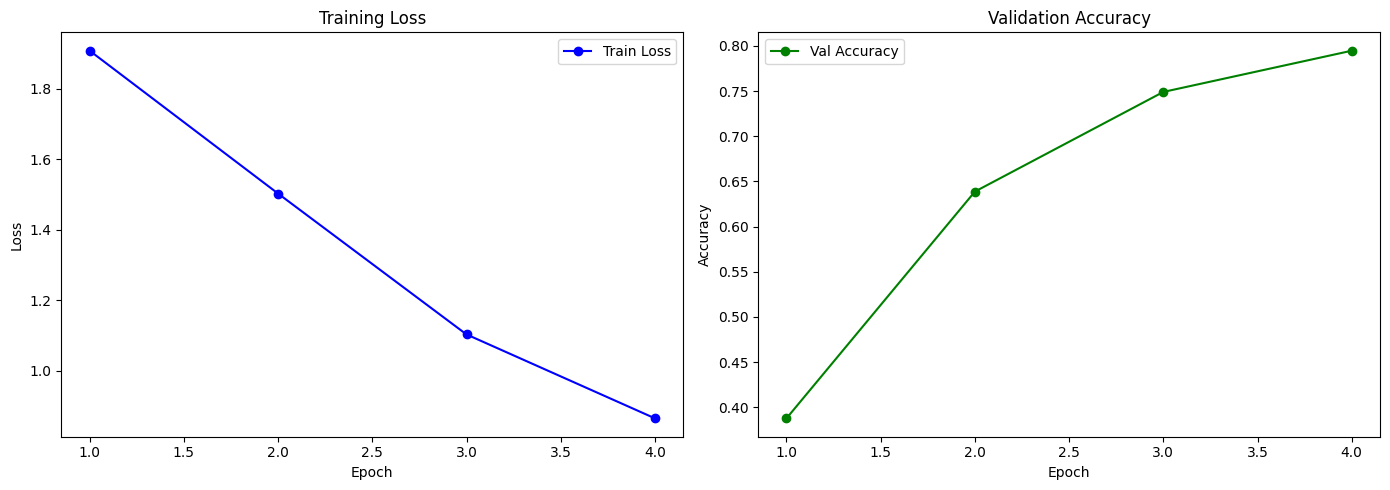

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].plot(range(1, EPOCHS+1), val_accuracies, 'g-o', label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Detailed Evaluation

In [8]:
# Classification report
target_names = label_encoder.classes_
print("Classification Report:")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

Classification Report:
                            precision    recall  f1-score   support

           Buffer Overflow       1.00      0.79      0.88        14
                      CSRF       1.00      0.56      0.71         9
         Command Injection       0.00      0.00      0.00         8
Cross-Site Scripting (XSS)       0.85      0.92      0.88        24
         Denial of Service       0.95      0.62      0.75        29
    Information Disclosure       1.00      0.47      0.64        15
                     Other       0.70      0.96      0.81        91
     Remote Code Execution       0.74      0.73      0.74        48
             SQL Injection       1.00      0.96      0.98        25

                  accuracy                           0.79       263
                 macro avg       0.80      0.67      0.71       263
              weighted avg       0.80      0.79      0.78       263



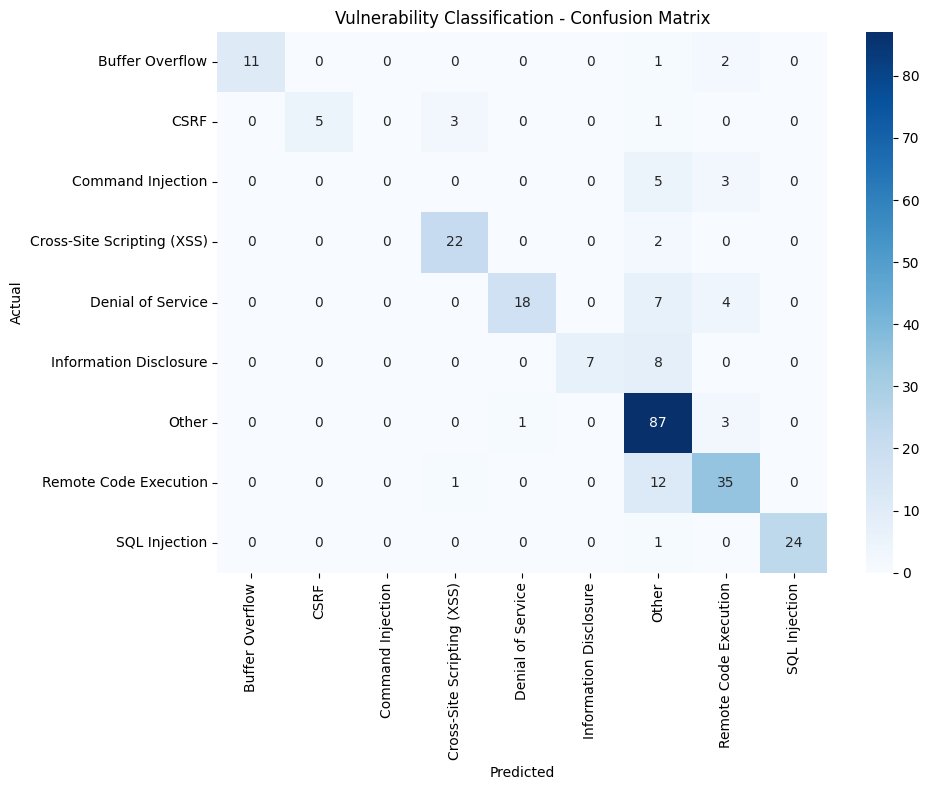

In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Vulnerability Classification - Confusion Matrix')
plt.tight_layout()
plt.savefig('../models/bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Test with Sample Descriptions

In [10]:
def predict_vulnerability_type(text, model, tokenizer, label_encoder, device):
    """Predict vulnerability type for a given description."""
    model.eval()
    encoding = tokenizer(
        text, add_special_tokens=True, max_length=256,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_label].item()

    return label_encoder.inverse_transform([pred_label])[0], confidence

# Test samples
test_descriptions = [
    "A buffer overflow vulnerability exists in Apache HTTP Server 2.4.58 that allows remote attackers to execute arbitrary code via crafted HTTP requests.",
    "SQL injection vulnerability in the login page of WebApp 3.2 allows remote attackers to bypass authentication.",
    "A cross-site scripting vulnerability exists in the admin panel that allows injection of malicious scripts.",
    "The application exposes sensitive user data including passwords in plaintext through an unprotected API endpoint.",
]

print("Sample Predictions:")
print("=" * 70)
for desc in test_descriptions:
    pred_type, conf = predict_vulnerability_type(desc, model, tokenizer, label_encoder, device)
    print(f"\nDescription: {desc[:100]}...")
    print(f"  Predicted Type: {pred_type}")
    print(f"  Confidence: {conf:.2%}")

Sample Predictions:

Description: A buffer overflow vulnerability exists in Apache HTTP Server 2.4.58 that allows remote attackers to ...
  Predicted Type: Remote Code Execution
  Confidence: 68.85%

Description: SQL injection vulnerability in the login page of WebApp 3.2 allows remote attackers to bypass authen...
  Predicted Type: SQL Injection
  Confidence: 44.28%

Description: A cross-site scripting vulnerability exists in the admin panel that allows injection of malicious sc...
  Predicted Type: Cross-Site Scripting (XSS)
  Confidence: 59.99%

Description: The application exposes sensitive user data including passwords in plaintext through an unprotected ...
  Predicted Type: Other
  Confidence: 74.77%


## 8. Save Model and Artifacts

In [11]:
import joblib

# Save model
model_save_path = '../models/bert_classifier'
model.save_pretrained(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label encoder
joblib.dump(label_encoder, '../models/label_encoder.joblib')

print("Saved:")
print(f"  - BERT model: {model_save_path}/")
print(f"  - Label encoder: models/label_encoder.joblib")
print(f"\nFinal accuracy: {val_accuracies[-1]:.4f}")
print("\n✅ BERT vulnerability classification complete!")

Saved:
  - BERT model: ../models/bert_classifier/
  - Label encoder: models/label_encoder.joblib

Final accuracy: 0.7947

✅ BERT vulnerability classification complete!
